In [8]:
import pandas as pd 
import numpy as np
import datetime         #Shows in my time zone COL.

8B51422X
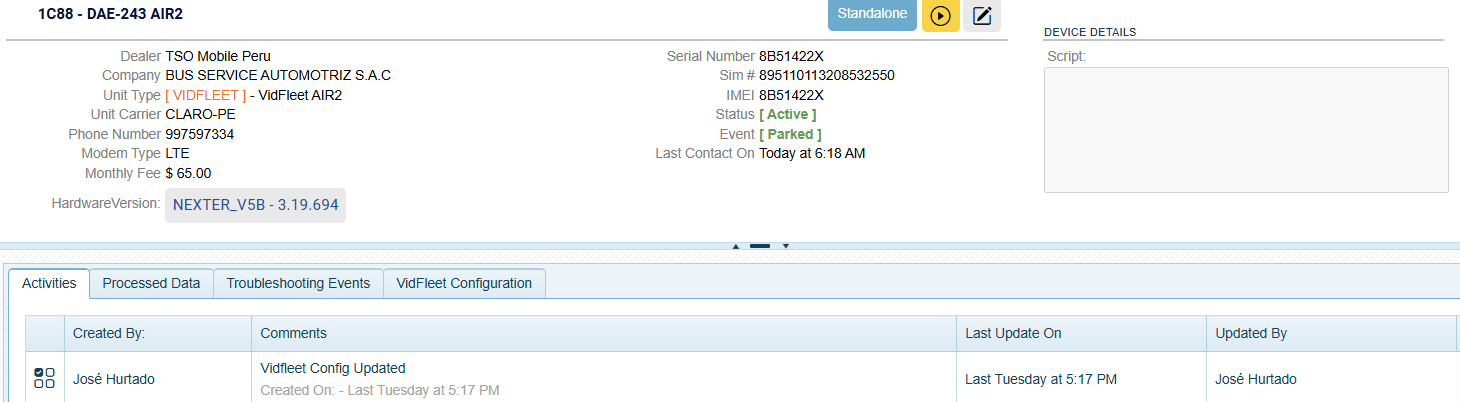

In [9]:
#vf=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sedisa\vck379.csv',sep=',')
#vf.info()

In [10]:
#11-08-2026 -> 13_08_2026
vf=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\bus_service\8B51422X_DAE-243 AIR2.xlsx')
vf.info()

<class 'pandas.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Columns: 212 entries, Message to Unnamed: 211
dtypes: float64(11), object(17), str(184)
memory usage: 1.1+ MB


In [11]:
vf['Message'].value_counts()

Message
{"notificationType":"TripInfo"              425
{"notificationType":"CameraRunningInfo"      92
{"notificationType":"AutoSnapshot"           79
{"notificationType":"IgnitionStatus"         48
{"notificationType":"ParkingHeartbeat"       34
{"notificationType":"CameraEvent"            17
{"notificationType":"MaintenanceWarning"      3
Name: count, dtype: int64

In [12]:
vf_camera_events=vf[vf['Message'].str.contains('CameraEvent')]
vf_camera_events['Unnamed: 4'].value_counts()

Unnamed: 4
event:"SHARP_TURN"     9
event:"HARD_ACCEL"     5
event:"HARD_BRAKE"     1
event:"YAWN"           1
event:"NO_SEATBELT"    1
Name: count, dtype: int64

In [13]:
vf_camera_events['Unnamed: 5'].value_counts()

Unnamed: 5
eventCategory:"SHARP_TURN"    9
eventCategory:"HARD_ACCEL"    5
eventCategory:"DMS"           2
eventCategory:"HARD_BRAKE"    1
Name: count, dtype: int64

In [14]:
vf_autosnapshot=vf[vf['Unnamed: 5'].str.contains('http')]
vf_autosnapshot['Unnamed: 5']#.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sedisa\snapshot.csv')

2      url:"https://cdn.vidfleet-api.gpstrackit.com/c...
8      url:"https://cdn.vidfleet-api.gpstrackit.com/c...
11     url:"https://cdn.vidfleet-api.gpstrackit.com/c...
23     url:"https://cdn.vidfleet-api.gpstrackit.com/c...
29     url:"https://cdn.vidfleet-api.gpstrackit.com/c...
                             ...                        
643    url:"https://cdn.vidfleet-api.gpstrackit.com/c...
656    url:"https://cdn.vidfleet-api.gpstrackit.com/c...
666    url:"https://cdn.vidfleet-api.gpstrackit.com/c...
677    url:"https://cdn.vidfleet-api.gpstrackit.com/c...
690    url:"https://cdn.vidfleet-api.gpstrackit.com/c...
Name: Unnamed: 5, Length: 79, dtype: str

In [15]:
vf_date_time=vf[vf['Unnamed: 3'].str.contains('time')]
vf_date_time['Unnamed: 3']
aux_date_time=[]
epoch_date=[]
vf_date_time['Date']='NaN'
#print(vf_date_time.iloc[0,103])

for i in range(0,vf_date_time.shape[0]):
    aux_date_time.append(float(vf_date_time.iloc[i,3][5:18])/1000)
    epoch_date.append(datetime.datetime.fromtimestamp(aux_date_time[i]))
    #vf_date_time.iloc[i,103]=str(epoch_date[i])

for i in range(0,len(epoch_date)):
    print(epoch_date[i],' -> ',aux_date_time[i])

2026-08-11 09:27:22  ->  1786458442.0
2026-08-11 09:30:47  ->  1786458647.0
2026-08-11 11:20:24  ->  1786465224.0
2026-08-11 11:30:24  ->  1786465824.0
2026-08-11 11:33:12  ->  1786465992.0
2026-08-11 17:05:53  ->  1786485953.0
2026-08-11 17:06:57  ->  1786486017.0
2026-08-11 17:07:31  ->  1786486051.0
2026-08-11 17:07:40  ->  1786486060.0
2026-08-11 17:10:03  ->  1786486203.0
2026-08-11 17:10:12  ->  1786486212.0
2026-08-11 17:10:22  ->  1786486222.0
2026-08-11 17:30:48  ->  1786487448.0
2026-08-11 17:31:55  ->  1786487515.0
2026-08-11 17:33:23  ->  1786487603.0
2026-08-12 08:35:43  ->  1786541743.0
2026-08-12 08:36:17  ->  1786541777.0
2026-08-12 08:36:26  ->  1786541786.0
2026-08-12 08:38:38  ->  1786541918.0
2026-08-12 08:39:14  ->  1786541954.0
2026-08-12 08:49:12.266000  ->  1786542552.266
2026-08-12 08:55:12.266000  ->  1786542912.266
2026-08-12 09:05:03  ->  1786543503.0
2026-08-12 09:15:03  ->  1786544103.0
2026-08-12 09:25:02.933000  ->  1786544702.933
2026-08-12 09:35:04.933

In [16]:
vf_autosnapshot=vf[vf['Unnamed: 5'].str.contains('http')]
vf_autosnapshot_date=[]
aux_date_time_as=[]
epoch_date_as=[]
vf_autosnapshot['Date']='NaN'

for i in range(0,vf_autosnapshot.shape[0]):
    aux_date_time_as.append(float(vf_date_time.iloc[i,3][5:18])/1000)
    epoch_date_as.append(datetime.datetime.fromtimestamp(aux_date_time[i]))
    #vf_autosnapshot.iloc[i,104]=str(epoch_date_as[i])

#vf_autosnapshot[['Unnamed: 5','Unnamed: 3','Date']].to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sedisa\autosnap_vck379.csv')       #Edit.

NO_SEATBELT


In [17]:
vf_no_seatbelt=vf[vf['Unnamed: 4'].str.contains('NO_SEATBELT')]
#vf_no_seatbelt

vf_date_time=vf_no_seatbelt[vf_no_seatbelt['Unnamed: 9'].str.contains('time')]
#vf_date_time['Unnamed: 9']
aux_date_time=[]
epoch_date=[]
vf_date_time['Date']='NaN'
speed=[]

for i in range(0,vf_date_time.shape[0]):
    aux_date_time.append(float(vf_date_time.iloc[i,9][5:18])/1000)
    epoch_date.append(datetime.datetime.fromtimestamp(aux_date_time[i]))    
    vf_date_time.iloc[i,103]=str(epoch_date[i])
    speed.append(vf_date_time.iloc[i,19])

for i in range(0,len(epoch_date)):
    print(epoch_date[i],' -> ',aux_date_time[i],' -> ',speed[i])

2026-08-19 17:23:46  ->  1787178226.0  ->  speed:11.008288


USING_PHONE

In [18]:
using_phone=vf[vf['Unnamed: 4'].str.contains('USING_PHONE')]
#vf_no_seatbelt

vf_date_time=using_phone[using_phone['Unnamed: 9'].str.contains('time')]
vf_date_time['Unnamed: 9']
aux_date_time=[]
epoch_date=[]
vf_date_time['Date']='NaN'
speed=[]

for i in range(0,vf_date_time.shape[0]):
    aux_date_time.append(float(vf_date_time.iloc[i,9][5:18])/1000)
    epoch_date.append(datetime.datetime.fromtimestamp(aux_date_time[i]))
    vf_date_time.iloc[i,103]=str(epoch_date[i])
    speed.append(vf_date_time.iloc[i,19])

for i in range(0,len(epoch_date)):
    print(epoch_date[i],' -> ',aux_date_time[i],' -> ',speed[i])

DROWSINESS

In [19]:
drowsiness=vf[vf['Unnamed: 4'].str.contains('DROWSINESS')]
#vf_no_seatbelt

vf_date_time=drowsiness[drowsiness['Unnamed: 9'].str.contains('time')]
vf_date_time['Unnamed: 9']
aux_date_time=[]
epoch_date=[]
vf_date_time['Date']='NaN'
speed=[]

for i in range(0,vf_date_time.shape[0]):
    aux_date_time.append(float(vf_date_time.iloc[i,9][5:18])/1000)
    epoch_date.append(datetime.datetime.fromtimestamp(aux_date_time[i]))
    vf_date_time.iloc[i,103]=str(epoch_date[i])
    speed.append(vf_date_time.iloc[i,20])

for i in range(0,len(epoch_date)):
    print(epoch_date[i],' -> ',aux_date_time[i],' -> ',speed[i])

YAWN

In [20]:
yawn=vf[vf['Unnamed: 4'].str.contains('YAWN')]
#vf_no_seatbelt

vf_date_time=yawn[yawn['Unnamed: 9'].str.contains('time')]
vf_date_time['Unnamed: 9']
aux_date_time=[]
epoch_date=[]
vf_date_time['Date']='NaN'
speed=[]

for i in range(0,vf_date_time.shape[0]):
    aux_date_time.append(float(vf_date_time.iloc[i,9][5:18])/1000)
    epoch_date.append(datetime.datetime.fromtimestamp(aux_date_time[i]))
    vf_date_time.iloc[i,103]=str(epoch_date[i])
    speed.append(vf_date_time.iloc[i,20])

for i in range(0,len(epoch_date)):
    print(epoch_date[i],' -> ',aux_date_time[i],' -> ',speed[i])

2026-08-19 05:12:08  ->  1787134328.0  ->  speed:44.01093


SHARP_TURN

In [21]:
sharp_turn=vf[vf['Unnamed: 4'].str.contains('SHARP')]
#vf_no_seatbelt

vf_date_time=sharp_turn[sharp_turn['Unnamed: 9'].str.contains('time')]
vf_date_time['Unnamed: 9']
aux_date_time=[]
epoch_date=[]
vf_date_time['Date']='NaN'
speed=[]

for i in range(0,vf_date_time.shape[0]):
    aux_date_time.append(float(vf_date_time.iloc[i,9][5:18])/1000)
    epoch_date.append(datetime.datetime.fromtimestamp(aux_date_time[i]))
    vf_date_time.iloc[i,103]=str(epoch_date[i])
    speed.append(vf_date_time.iloc[i,21])

for i in range(0,len(epoch_date)):
    print(epoch_date[i],' -> ',aux_date_time[i],' -> ',speed[i])

2026-08-18 16:30:44  ->  1787088644.0  ->  speed:13.39922
2026-08-18 18:17:39  ->  1787095059.0  ->  speed:12.200976
2026-08-18 19:14:04  ->  1787098444.0  ->  speed:15.306779
2026-08-19 05:07:37  ->  1787134057.0  ->  speed:9.348896
2026-08-19 05:08:16  ->  1787134096.0  ->  speed:13.869627
2026-08-19 05:08:26  ->  1787134106.0  ->  speed:14.656727
2026-08-19 16:31:43  ->  1787175103.0  ->  speed:8.285847
2026-08-19 16:32:25  ->  1787175145.0  ->  speed:11.819463
2026-08-19 18:17:09  ->  1787181429.0  ->  speed:5.826392


HARD_BRAKE

In [22]:
hard_brake=vf[vf['Unnamed: 4'].str.contains('HARD')]
#vf_no_seatbelt

vf_date_time=hard_brake[hard_brake['Unnamed: 9'].str.contains('time')]
vf_date_time['Unnamed: 9']
aux_date_time=[]
epoch_date=[]
vf_date_time['Date']='NaN'
speed=[]

for i in range(0,vf_date_time.shape[0]):
    aux_date_time.append(float(vf_date_time.iloc[i,9][5:18])/1000)
    epoch_date.append(datetime.datetime.fromtimestamp(aux_date_time[i]))
    vf_date_time.iloc[i,103]=str(epoch_date[i])
    speed.append(vf_date_time.iloc[i,20])

for i in range(0,len(epoch_date)):
    print(epoch_date[i],' -> ',aux_date_time[i],' -> ',speed[i])

2026-08-12 09:14:34  ->  1786544074.0  ->  speed:8.543275
2026-08-18 16:57:57  ->  1787090277.0  ->  speed:9.26
2026-08-18 19:19:34  ->  1787098774.0  ->  speed:11.169411
2026-08-18 19:22:45  ->  1787098965.0  ->  time:1787098964000
2026-08-19 16:45:10  ->  1787175910.0  ->  speed:12.99178
2026-08-19 16:45:13  ->  1787175913.0  ->  speed:19.48304
